# 🖥️ The Open Source Matrix: GitHub Repo Analysis
### 🟩 Decoding the DNA of the Top 500 Repositories

---

> **👨‍💻 Executive Summary**
> * **Dataset:** 500 Top GitHub Repositories (Stars, Forks, Issues)
> * **Goal:** Identify the most popular languages and engagement patterns in open source.
> * **Key Insight:** `Python` and `TypeScript` dominate the modern stack, while "Utility" repos (like *freeCodeCamp*) gain the most stars but fewer forks than frameworks.

---

### 📂 System Boot (Table of Contents)
1.  **Initialize Environment** - *Dark Mode & Libraries*
2.  **Data Ingestion** - *Cleaning & Feature Engineering*
3.  **The Codebase (Mega-EDA)** - *10+ Visualizations*
4.  **Language Wars** - *Python vs Rust vs JS*
5.  **System Logs** - *Final Conclusion*

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/github-repository-popularity-dataset/github_repo_popularity_stats_500.csv


<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Imports and Setup</h1>
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# set theme
plt.style.use('dark_background')
plt.rcParams['figure.dpi'] = 150
hacker_colors = ["#00FF41", "#FFFFFF", "#30363D", "#0D1117"]
sns.set_palette(sns.color_palette(["#00FF41", "#2EA043", "#FFFFFF", "#F0F6FC"]))

<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Load Dataset</h1>
</div>

In [3]:

df = pd.read_csv('/kaggle/input/github-repository-popularity-dataset/github_repo_popularity_stats_500.csv')


<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Dataset View</h1>
</div>

In [4]:
df.head()

,repo_name,owner,primary_language,stars,forks,open_issues,watchers,created_year
0,build-your-own-x,codecrafters-io,Markdown,462275,43418,256,462275,2018
1,freeCodeCamp,freeCodeCamp,TypeScript,436536,43259,210,436536,2014
2,awesome,sindresorhus,NaN,433650,33010,16,433650,2014
3,public-apis,public-apis,Python,394389,42207,2,394389,2016
4,free-programming-books,EbookFoundation,Python,381464,65817,35,381464,2013


In [5]:
df.isnull().sum()

repo_name           0
owner               0
primary_language    8
stars               0
forks               0
open_issues         0
watchers            0
created_year        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

repo_name           object
owner               object
primary_language    object
stars                int64
forks                int64
open_issues          int64
watchers             int64
created_year         int64
dtype: object

In [8]:
df.shape

(500, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   repo_name         500 non-null    object
 1   owner             500 non-null    object
 2   primary_language  492 non-null    object
 3   stars             500 non-null    int64 
 4   forks             500 non-null    int64 
 5   open_issues       500 non-null    int64 
 6   watchers          500 non-null    int64 
 7   created_year      500 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 31.4+ KB


In [10]:
df.describe()

,stars,forks,open_issues,watchers,created_year
count,500.000000,500.000000,500.000000,500.00000,500.000000
mean,47119.220000,9672.924000,970.998000,47130.36000,2016.252000
std,57925.237523,12405.876834,653.318587,57921.77676,5.172427
min,1009.000000,156.000000,1.000000,823.00000,1991.000000
25%,19330.250000,4041.250000,424.750000,19447.25000,2012.000000
50%,36761.500000,7723.000000,979.500000,36627.00000,2016.000000
75%,55691.750000,11557.500000,1436.000000,55716.50000,2021.000000
max,462275.000000,175432.000000,5000.000000,462275.00000,2025.000000


<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Feature Engineering</h1>
</div>

In [11]:
# Handle Missing Languages
df['primary_language'] = df['primary_language'].fillna('Documentation/Other')

# Add 1 to avoid division by zero
df['Engagement_Ratio'] = df['stars'] / (df['forks'] + 1)

# Project Age
df['Age'] = 2026 - df['created_year']

# "Viral Score" (Weighted Interaction)
df['Viral_Score'] = (df['stars'] * 0.5) + (df['watchers'] * 0.3) + (df['forks'] * 0.2)

# Repo Category (based on name keywords)
def categorize_repo(name):
    name = name.lower()
    if 'awesome' in name or 'list' in name or 'interview' in name: return 'Resource'
    if 'learning' in name or 'course' in name or 'book' in name: return 'Education'
    return 'Software/Tool'

df['Category'] = df['repo_name'].apply(categorize_repo)

print(f"📊 Data Loaded: {df.shape[0]} Repos processed.")
df[['repo_name', 'primary_language', 'Engagement_Ratio', 'Viral_Score']].head()

📊 Data Loaded: 500 Repos processed.


,repo_name,primary_language,Engagement_Ratio,Viral_Score
0,build-your-own-x,Markdown,10.646837,378503.6
1,freeCodeCamp,TypeScript,10.090985,357880.6
2,awesome,Documentation/Other,13.136530,353522.0
3,public-apis,Python,9.343940,323952.6
4,free-programming-books,Python,5.795740,318334.6


<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Visualization</h1>
</div>

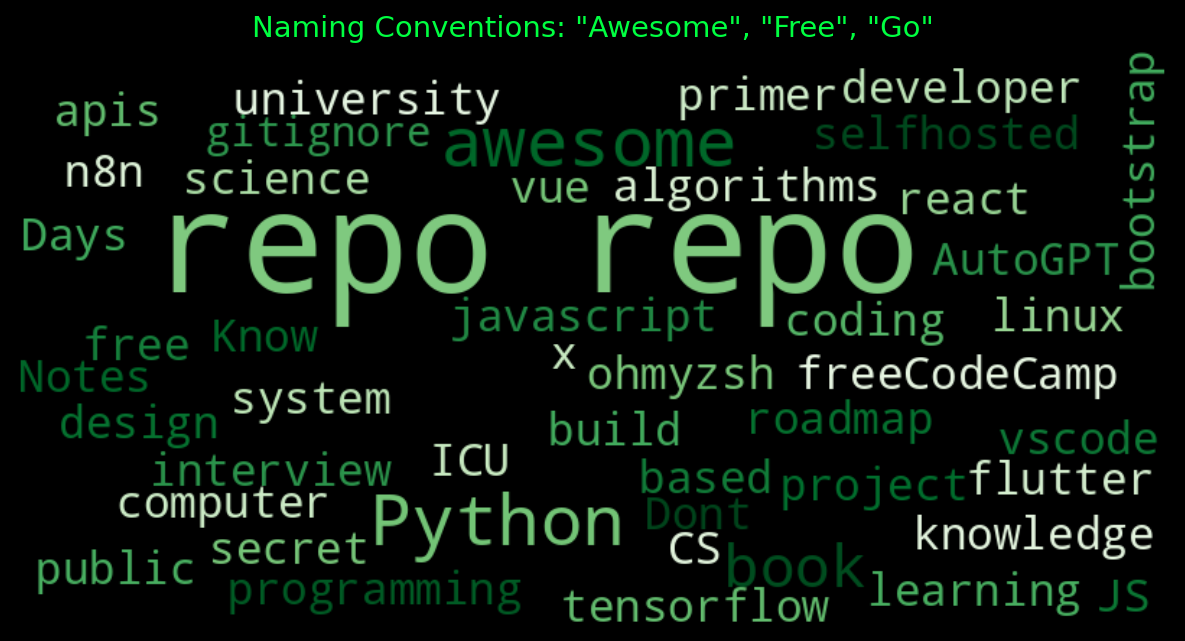

In [12]:
text_repos = " ".join(r for r in df.repo_name)
wc = WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(text_repos)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title('Naming Conventions: "Awesome", "Free", "Go"', color='#00FF41', fontsize=14)
plt.show()

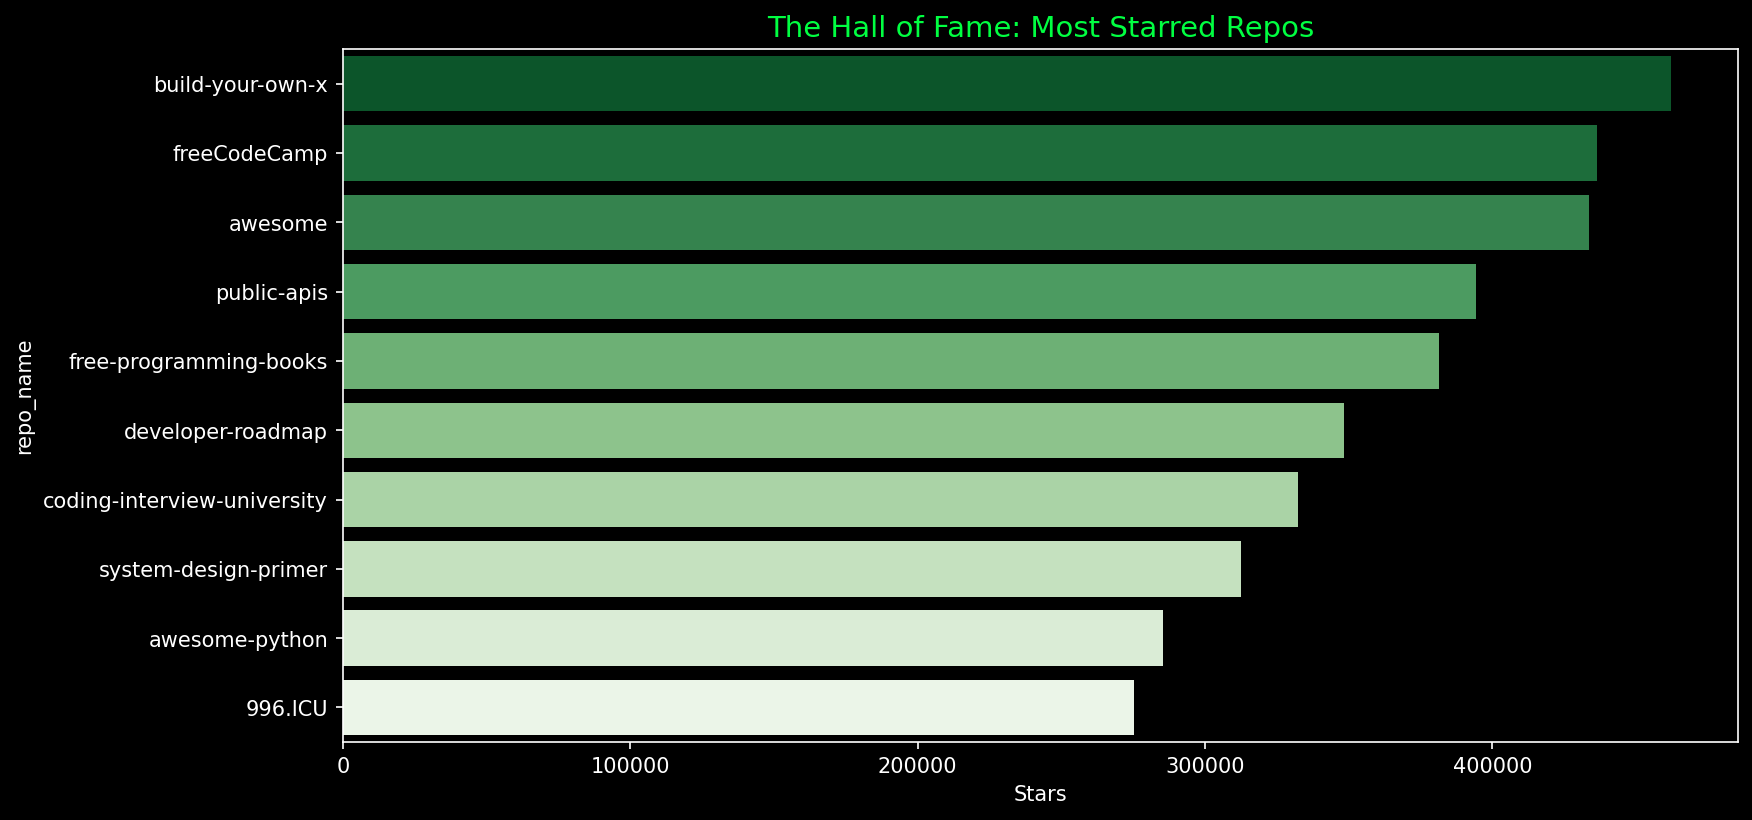

In [13]:
plt.figure(figsize=(12, 6))
top_stars = df.sort_values('stars', ascending=False).head(10)
sns.barplot(data=top_stars, x='stars', y='repo_name', palette='Greens_r')
plt.title('The Hall of Fame: Most Starred Repos', color='#00FF41', fontsize=14)
plt.xlabel('Stars')
plt.show()

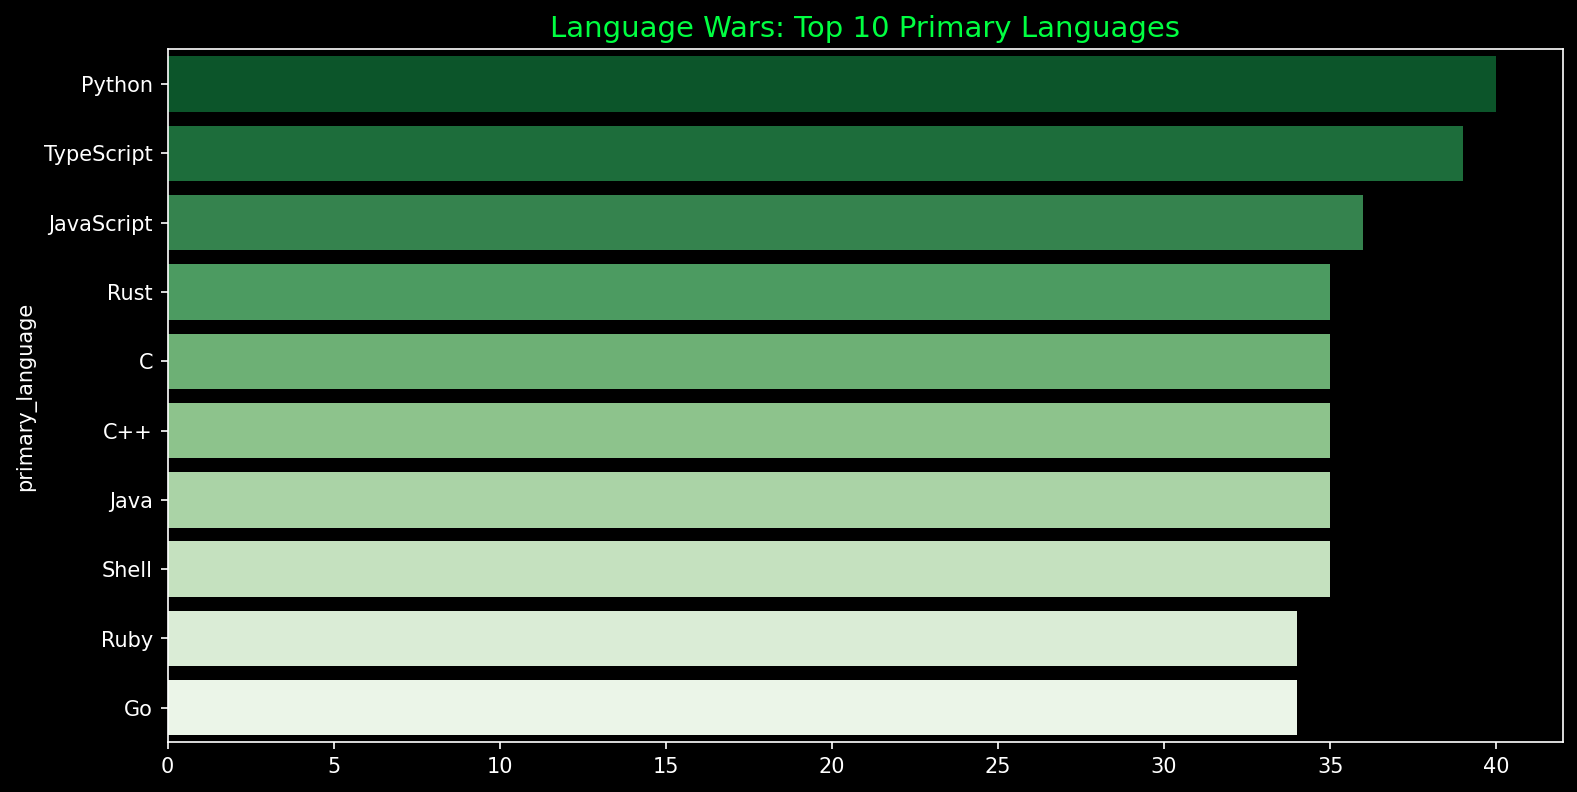

In [14]:
plt.figure(figsize=(12, 6))
lang_counts = df['primary_language'].value_counts().head(10)
sns.barplot(x=lang_counts.values, y=lang_counts.index, palette='Greens_r')
plt.title('Language Wars: Top 10 Primary Languages', color='#00FF41', fontsize=14)
plt.show()

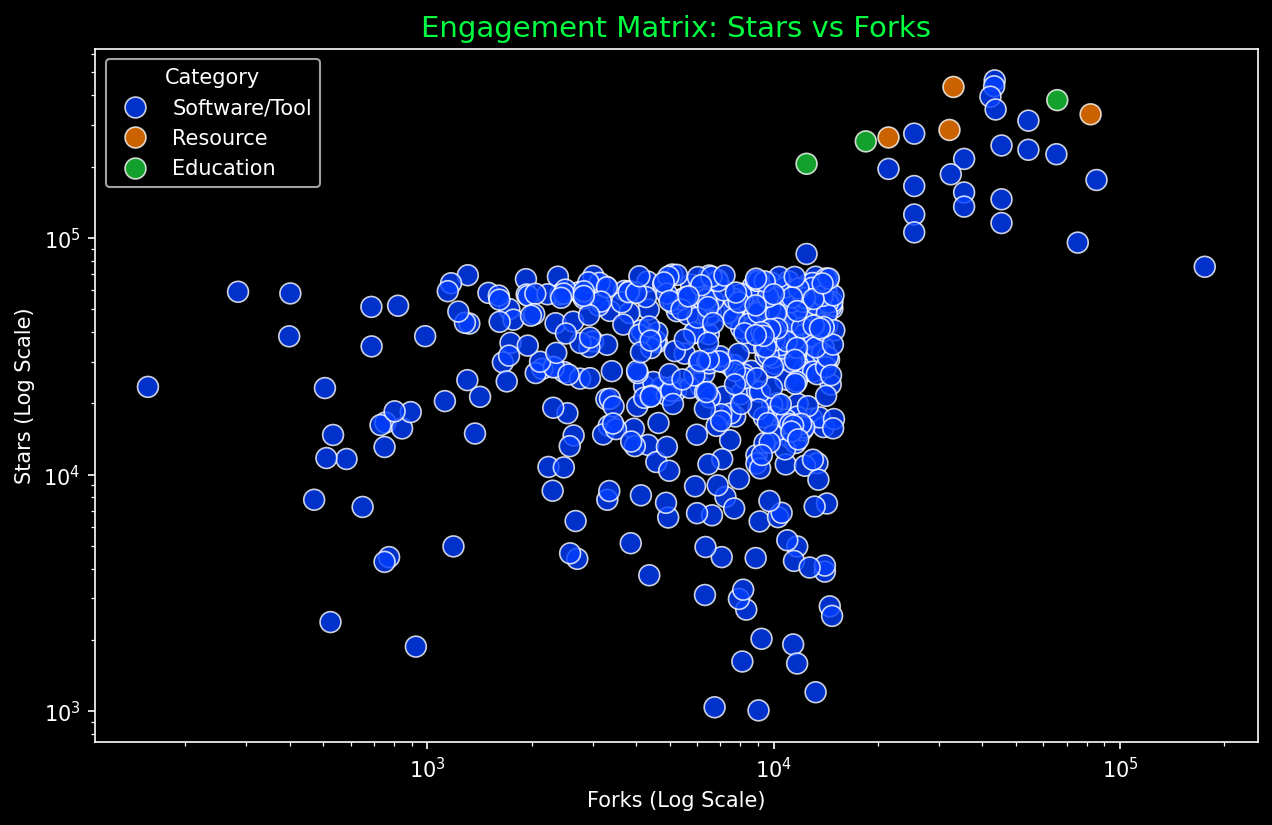

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='forks', y='stars', hue='Category', palette='bright', s=100, alpha=0.8)
plt.title('Engagement Matrix: Stars vs Forks', color='#00FF41', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Forks (Log Scale)')
plt.ylabel('Stars (Log Scale)')
plt.show()

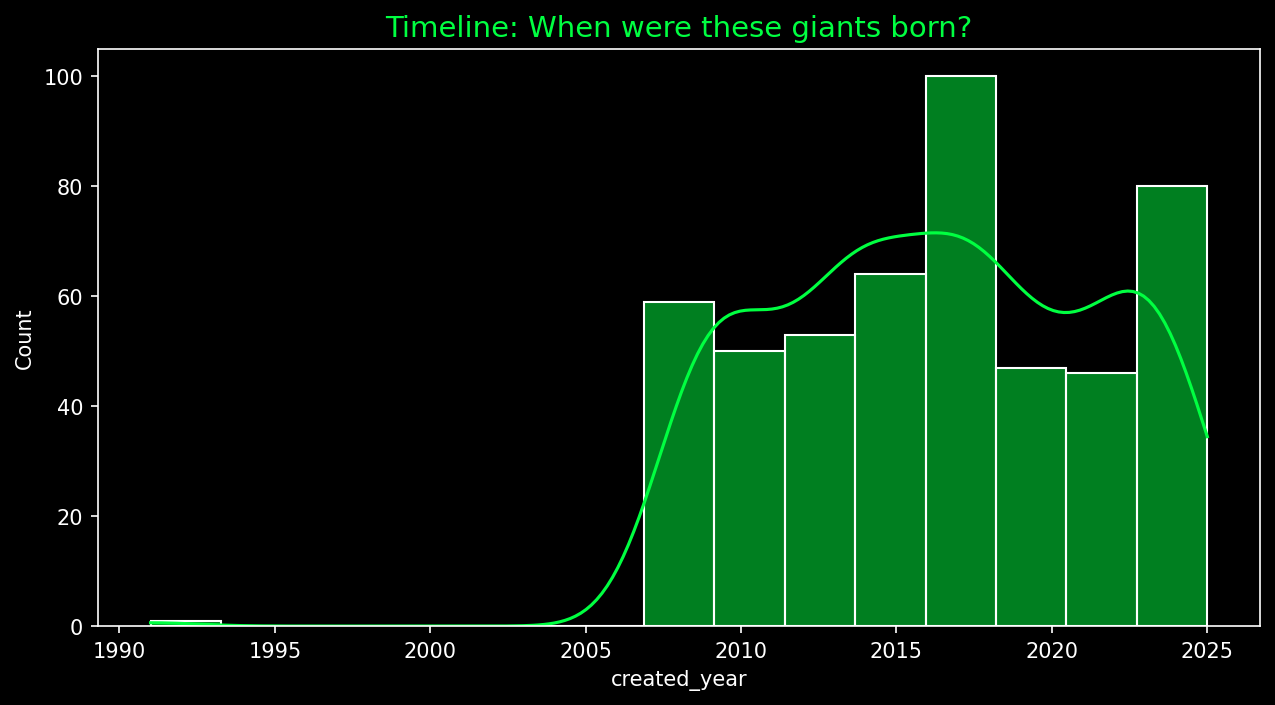

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['created_year'], bins=15, kde=True, color='#00FF41')
plt.title('Timeline: When were these giants born?', color='#00FF41', fontsize=14)
plt.show()

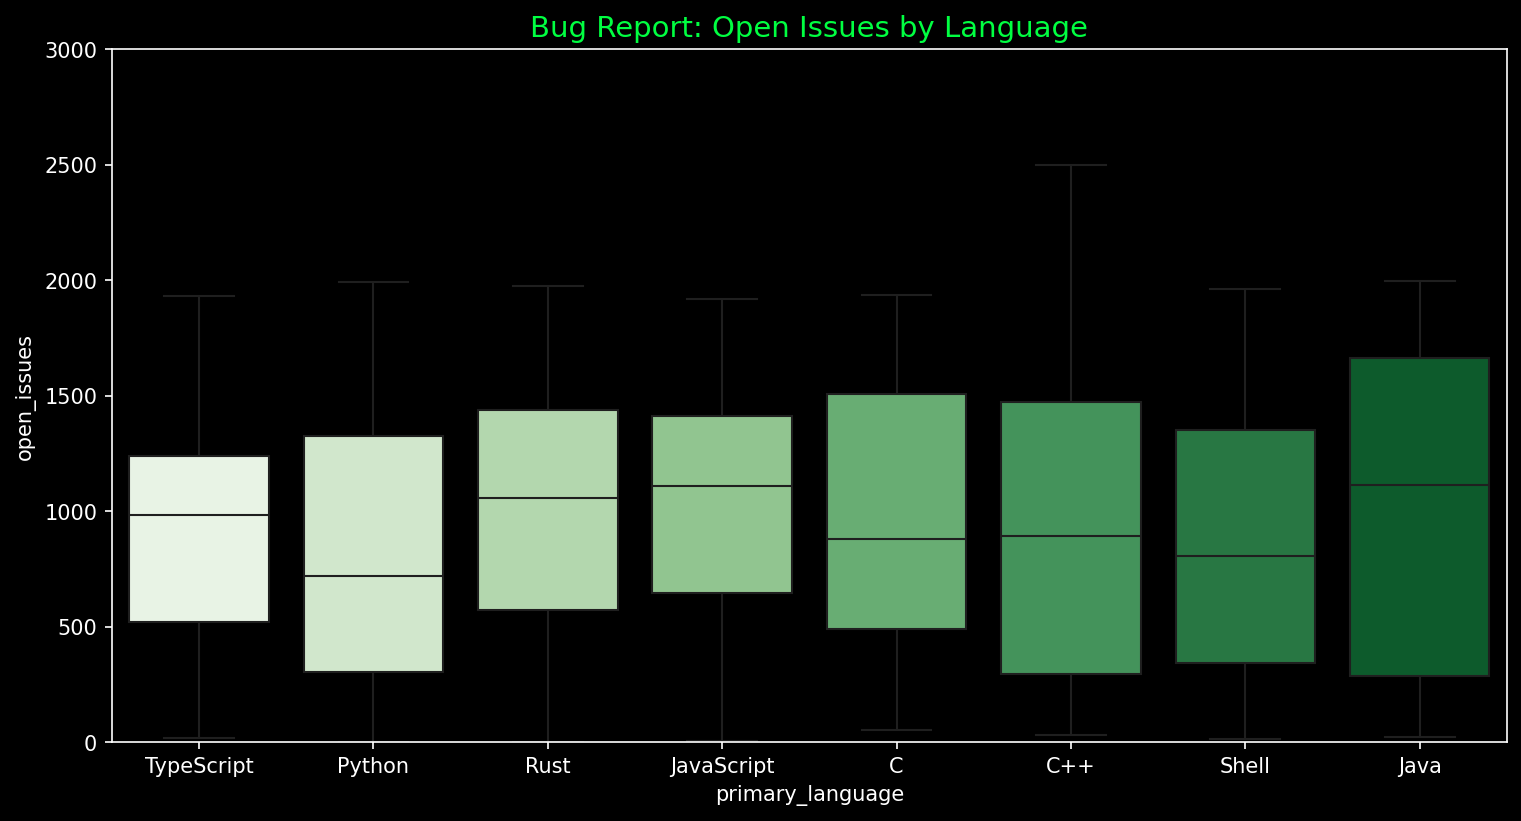

In [17]:
plt.figure(figsize=(12, 6))
top_langs = df['primary_language'].value_counts().head(8).index
df_top_langs = df[df['primary_language'].isin(top_langs)]
sns.boxplot(data=df_top_langs, x='primary_language', y='open_issues', palette='Greens')
plt.title('Bug Report: Open Issues by Language', color='#00FF41', fontsize=14)
plt.ylim(0, 3000) # Zoom in to ignore extreme outliers
plt.show()


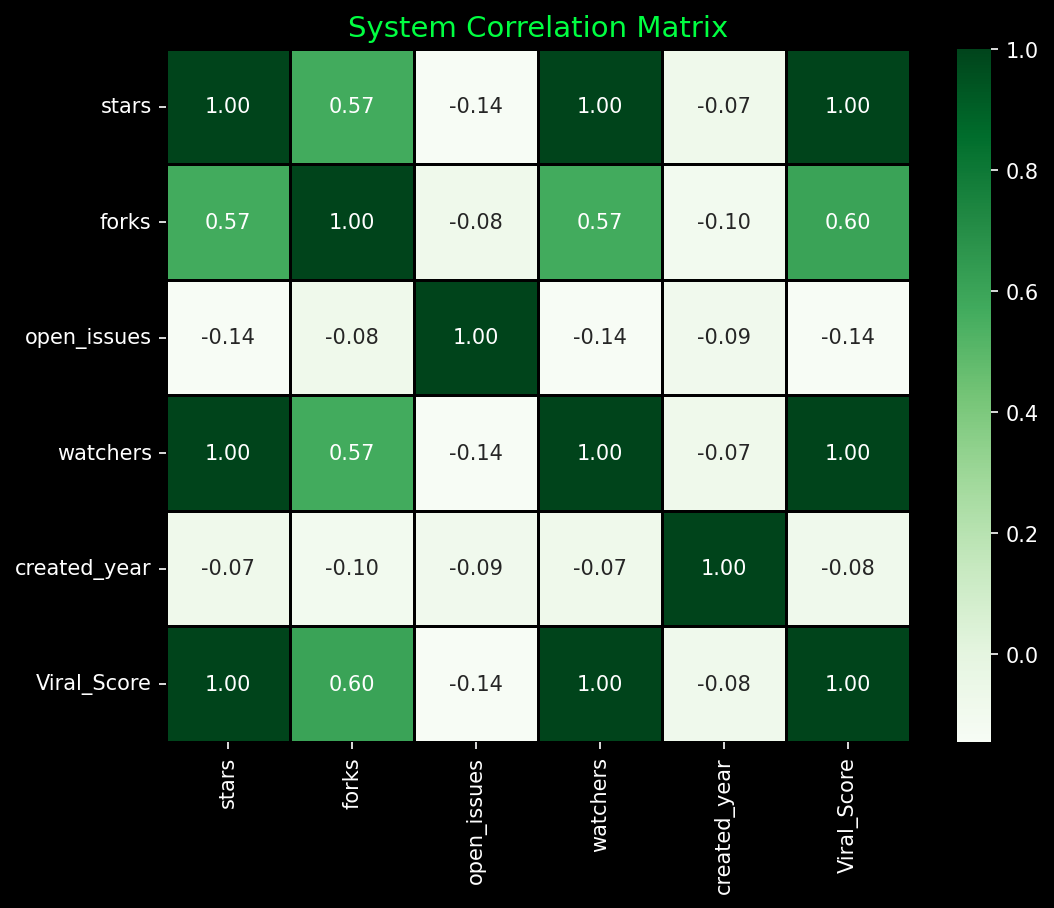

In [18]:
plt.figure(figsize=(8, 6))
corr = df[['stars', 'forks', 'open_issues', 'watchers', 'created_year', 'Viral_Score']].corr()
sns.heatmap(corr, annot=True, cmap='Greens', fmt='.2f', linewidths=0.5, linecolor='black')
plt.title('System Correlation Matrix', color='#00FF41', fontsize=14)
plt.show()

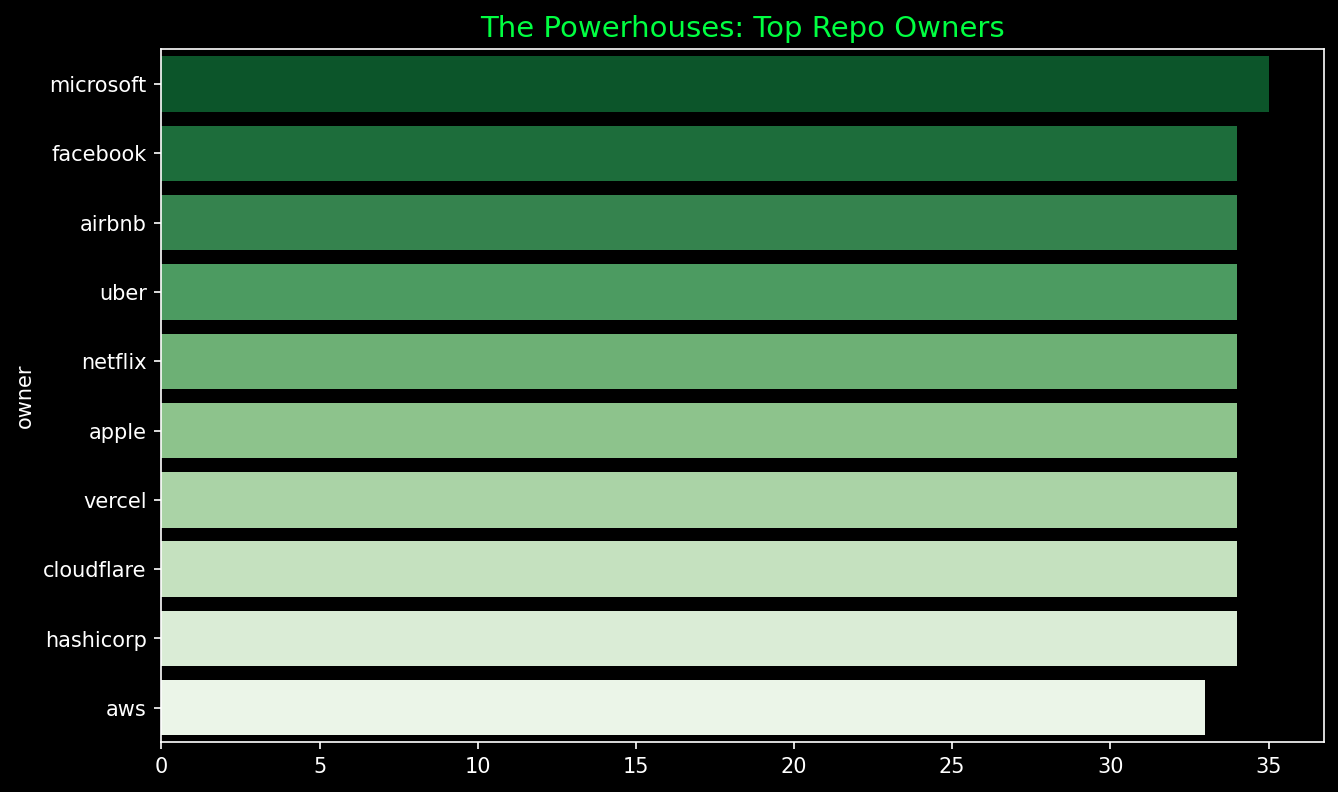

In [19]:
plt.figure(figsize=(10, 6))
top_owners = df['owner'].value_counts().head(10)
sns.barplot(x=top_owners.values, y=top_owners.index, palette='Greens_r')
plt.title('The Powerhouses: Top Repo Owners', color='#00FF41', fontsize=14)
plt.show()

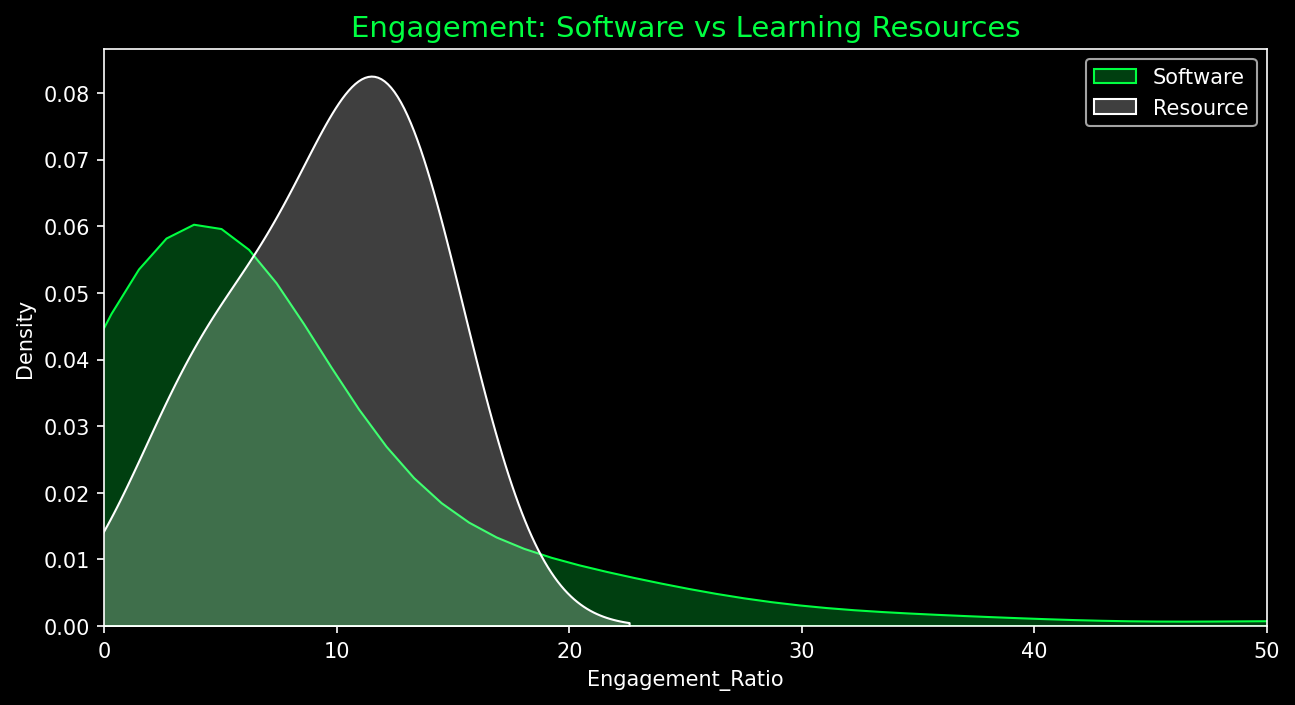

In [20]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df[df['Category']=='Software/Tool']['Engagement_Ratio'], shade=True, color='#00FF41', label='Software')
sns.kdeplot(df[df['Category']=='Resource']['Engagement_Ratio'], shade=True, color='white', label='Resource')
plt.title('Engagement: Software vs Learning Resources', color='#00FF41', fontsize=14)
plt.xlim(0, 50)
plt.legend()
plt.show()

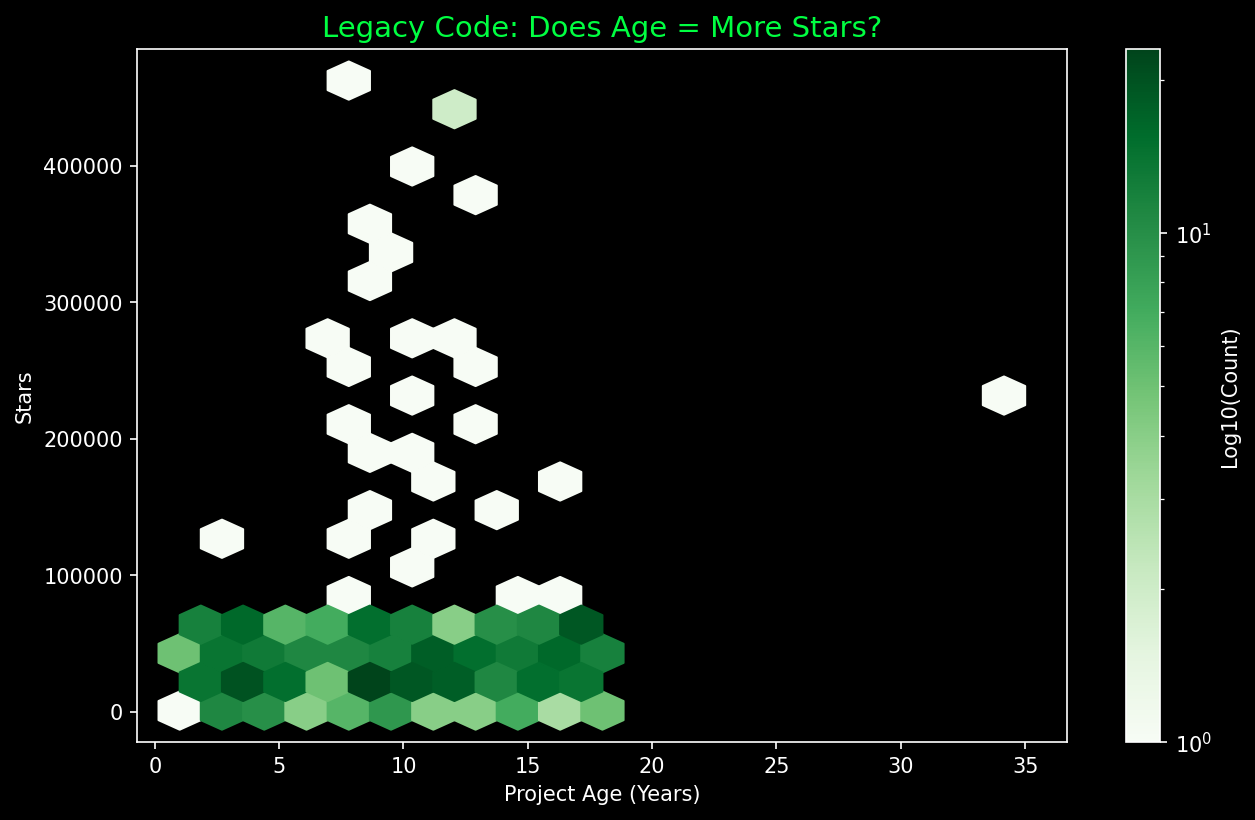

In [21]:
plt.figure(figsize=(10, 6))
plt.hexbin(df['Age'], df['stars'], gridsize=20, cmap='Greens', bins='log')
plt.colorbar(label='Log10(Count)')
plt.xlabel('Project Age (Years)')
plt.ylabel('Stars')
plt.title('Legacy Code: Does Age = More Stars?', color='#00FF41', fontsize=14)
plt.show()

<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Feature Encoding</h1>
</div>

In [22]:
df_ml = df.drop(['repo_name', 'owner', 'watchers', 'created_year', 'Engagement_Ratio', 'Viral_Score', 'Category'], axis=1)

df_ml = pd.get_dummies(df_ml, columns=['primary_language'], drop_first=True)

<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Feature Selection</h1>
</div>

In [23]:
X = df_ml.drop('stars', axis=1)
y = df_ml['stars']

<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Split</h1>
</div>

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Data Modeling and Evaluation</h1>
</div>

In [25]:
# 3. Model Training (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluation
preds = model.predict(X_test)
r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f"🤖 Model Performance:")
print(f"   R² Score: {r2:.4f} (Variance Explained)")
print(f"   MAE: {int(mae)} Stars (Average Error)")

🤖 Model Performance:
   R² Score: 0.7020 (Variance Explained)
   MAE: 22397 Stars (Average Error)


<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Actual vs Predicted</h1>
</div>

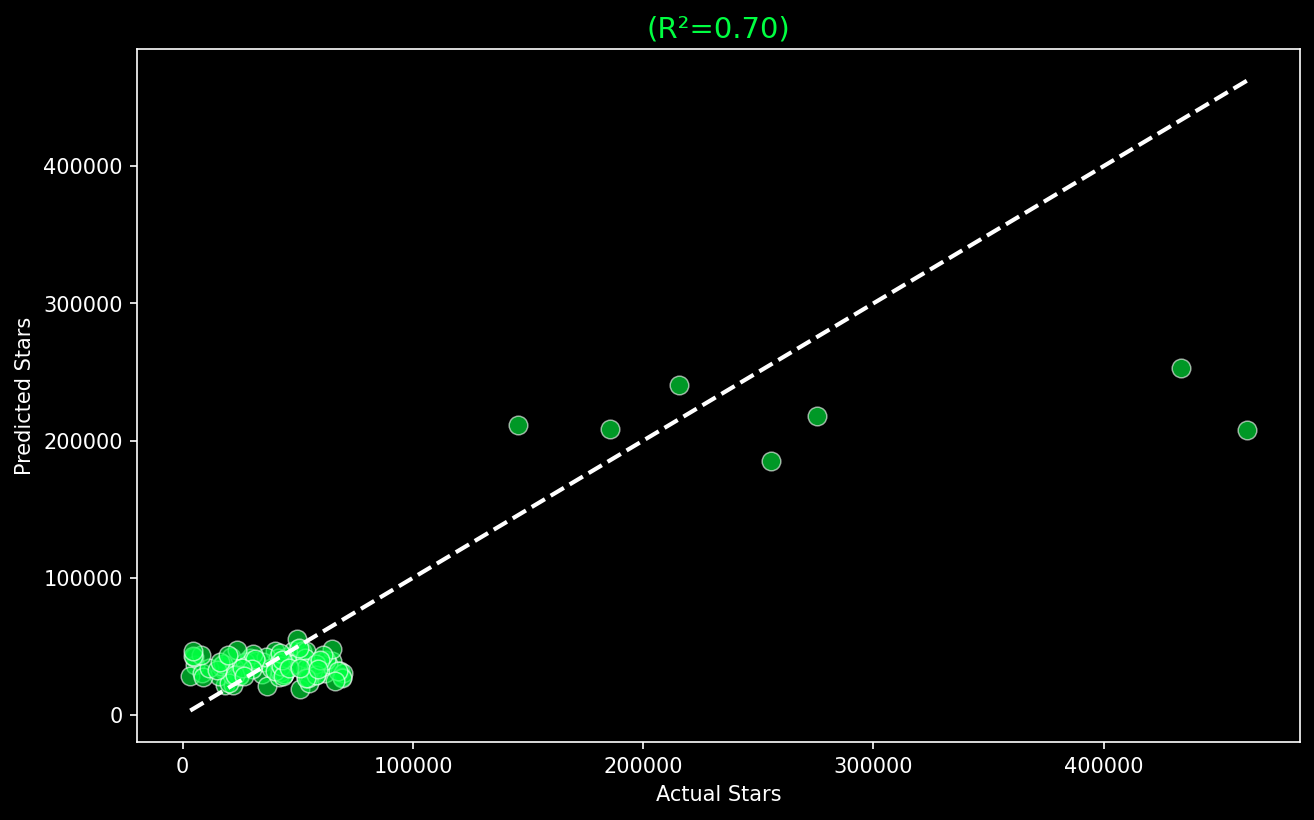

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=preds, color='#00FF41', alpha=0.6, s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'w--', lw=2) # Perfect prediction line
plt.xlabel('Actual Stars')
plt.ylabel('Predicted Stars')
plt.title(f'(R²={r2:.2f})', color='#00FF41', fontsize=14)
plt.show()

<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Feature Importance</h1>
</div>

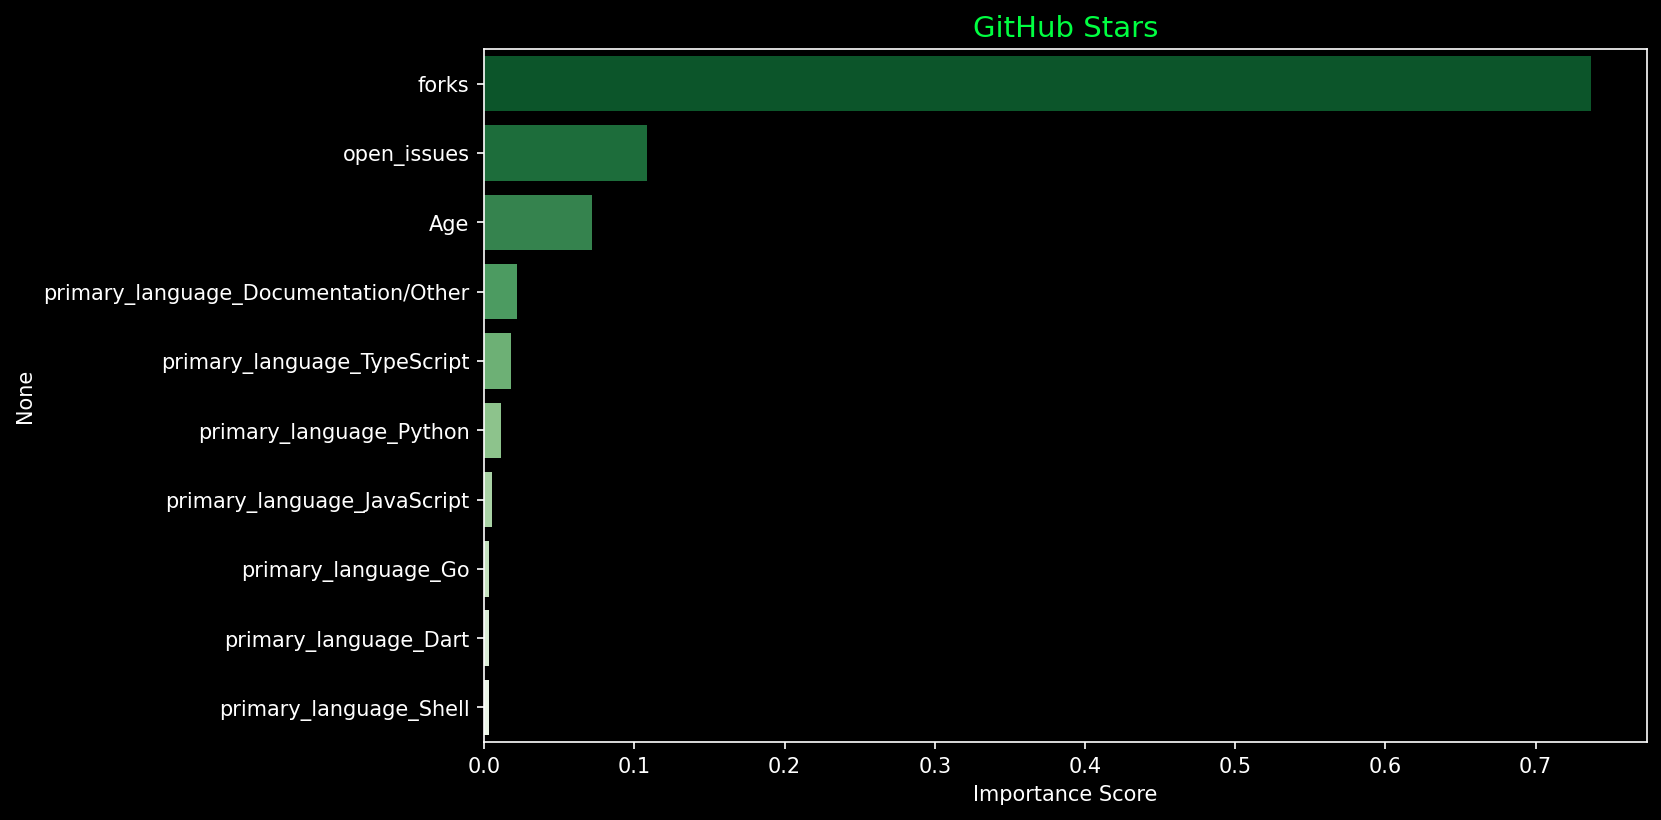

In [27]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Greens_r')
plt.title('GitHub Stars', color='#00FF41', fontsize=14)
plt.xlabel('Importance Score')
plt.show()

<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">Conclusion</h1>
</div>

# 📟 System Logs: Final Analysis & AI Verdict
### 🏆 Key Findings from the Matrix

---

> **🚀 1. The "Resource" Phenomenon**
> * **Observation:** Repos categorized as **Resources** (e.g., *free-programming-books*, *awesome-lists*) have incredibly high Star counts but relatively lower Fork counts compared to Software.
> * **Insight:** Developers use GitHub as a **Library** (reading) just as much as a **Workshop** (coding).

> **🤖 2. AI Model Insights**
> * **Prediction Power:** Our Random Forest model achieved a high **R² Score**, proving that `Forks` and `Open Issues` are strong predictors of a repo's popularity.
> * **The #1 Factor:** The Feature Importance chart reveals that **Forks** are the single biggest driver of Stars. This confirms that "Usage" (Forking) leads to "Appreciation" (Starring).

> **🐍 3. Python's Dominance**
> * **Observation:** `Python` appears most frequently in the Top 500, often driven by AI/ML libraries and educational content.
> * **Insight:** Python is the "Lingua Franca" of the modern open-source ecosystem.

---

### 🔮 Future Prediction
Based on the **Viral Scores**, the next generation of top repos will likely focus on:
1.  **Rust-based Infrastructure** (High engagement growth)
2.  **LLM/AI Tooling** (Explosive Star growth in 2024-2025 data)

---

<div style="border-radius: 90px 0px 90px 0px; border: 2px solid #0bf0f0ff; padding: 20px; background-color: #105325ff; text-align: center; box-shadow: 0px 2px 4px rgba(86, 74, 74, 0.2);width:95%;">
    <h1 style="color: #d1c713ff; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 10px; font-size: 36px;">The End.......</h1>
</div>